# scikit-fair examples - simple comparative study

Quick benchmark of all scikit-fair preprocessing methods across three fairness datasets,
evaluated with **5-fold stratified cross-validation**.

This notebook is meant to validate the implementation of the package, and does not serve as a comprehensive comparative study of the methods. This will be the subject of a future paper.

| | |
|---|---|
| **Datasets** | Adult, German, Heart Disease (sens_attr = sex, in all of them) |
| **Classifiers** | LogReg, SVC, RF, XGB |
| **Methods** | Baseline (no method) + 11 fairness algorithms |
| **Metrics** | Accuracy, Balanced Accuracy, Disparate Impact, SPD, EOD, AOD |

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.base import clone
from imblearn.pipeline import Pipeline as ImbPipeline

from skfair.datasets import load_adult, load_german, load_heart_disease
from skfair.preprocessing import (
    Massaging,
    FairSmote,
    FairOversampling,
    FAWOS,
    HeterogeneousFOS,
    FairwayRemover,
    GeometricFairnessRepair,
    LearningFairRepresentations,
    ReweighingClassifier,
    FairBalanceClassifier,
    FairMask,
)
from skfair.metrics import (
    accuracy,
    balanced_accuracy,
    disparate_impact,
    statistical_parity_difference,
    equal_opportunity_difference,
    average_odds_difference,
)

sns.set_theme(style="whitegrid")
print("Imports OK")

Imports OK


## 1. Datasets

In [2]:
datasets = {
   # "Adult":         load_adult(preprocessed=True),
    "German":        load_german(preprocessed=True),
    "Heart Disease": load_heart_disease(preprocessed=True),
}

for name, (X, y) in datasets.items():
    pos_rate = float(np.mean(y))
    sex_rate = float(np.mean(X["sex"]))
    print(f"{name:15s}: {X.shape[0]:6d} samples, {X.shape[1]:3d} features"
          f"  | pos_rate={pos_rate:.2f}  male_rate={sex_rate:.2f}")

German         :   1000 samples,  46 features  | pos_rate=0.70  male_rate=0.69
Heart Disease  :    270 samples,  13 features  | pos_rate=0.56  male_rate=0.68


## 2. Classifiers

In [3]:
CLASSIFIERS = {
    "LogReg": LogisticRegression(solver="liblinear", max_iter=1000, random_state=42),
    "SVC":    SVC(probability=True, kernel="rbf", random_state=42),
    "RF":     RandomForestClassifier(n_estimators=100, random_state=42),
    "XGB":    XGBClassifier(n_estimators=100, random_state=42, eval_metric="logloss", verbosity=0),
}
print("Classifiers:", list(CLASSIFIERS.keys()))

Classifiers: ['LogReg', 'SVC', 'RF', 'XGB']


## 3. Method Factory

Each method is wrapped in an `ImbPipeline`:

- **Baseline**: `[clf]`
- **Samplers** (Massaging, FairSmote, FairOversampling, FAWOS, HeterogeneousFOS, FairwayRemover): `[method → clf]`
- **Transformers** (GeometricFairnessRepair, LFR): `[method → clf]`
- **Meta-estimators** (ReweighingClassifier, FairBalanceClassifier, FairMask): `[clf(estimator=...)]`

> **Skipped**: `OptimizedPreprocessing` (requires discretized features + custom distortion function),
> `IntersectionalBinarizer` (we focus on sex only in this notebook) 

DropColumns (optional) → Drop protected attribute before inference.

In [ ]:

# --- Method registry ---
# Each entry: (MethodClass, kwargs_dict)
#   - "sampler/transformer" methods go before the clf in the pipeline
#   - "meta" methods wrap the clf as estimator=
#   - Baseline has no method step

SAMPLERS = {
    "Massaging":       (Massaging,       {"sens_attr": "sex", "priv_group": 1}),
    "FairSmote":       (FairSmote,       {"sens_attr": "sex", "random_state": 42}),
    "FairOversampling":(FairOversampling, {"sens_attr": "sex", "priv_group": 1, "random_state": 42}),
    "FAWOS":           (FAWOS,           {"sens_attr": "sex", "priv_group": 1, "random_state": 42}),
    "HeterogeneousFOS":(HeterogeneousFOS, {"sens_attr": "sex", "random_state": 42}),
    "FairwayRemover":  (FairwayRemover,  {"sens_attr": "sex", "priv_group": 1}),
}

# These need numeric_cols from X, resolved at build time
REPAIR_METHODS = {
    "GeometricFairnessRepair": (GeometricFairnessRepair, lambda cols: {
        "sensitive_attribute": "sex", "repair_columns": cols, "lambda_param": 1.0,
    }),
    "LearningFairRepresentations": (LearningFairRepresentations, lambda cols: {
        "sensitive_attribute": "sex", "priv_group": 1, "random_state": 42,
    }),
}

META_ESTIMATORS = {
    "ReweighingClassifier":  (ReweighingClassifier,  {"sens_attr": "sex"}),
    "FairBalanceClassifier": (FairBalanceClassifier,  {"sens_attr": "sex"}),
    "FairMask":              (FairMask,              {"sens_attr": "sex", "random_state": 42}),
}

METHODS = ["Baseline"] + list(SAMPLERS) + list(REPAIR_METHODS) + list(META_ESTIMATORS)


def build_pipeline(method_key, clf_name, clf, X):
    """Return an ImbPipeline for (method, clf) fitted to a dataset with schema X."""
    clf = clone(clf)

    if method_key == "Baseline":
        return ImbPipeline([("clf", clf)])

    if method_key in SAMPLERS:
        cls, kw = SAMPLERS[method_key]
        return ImbPipeline([("method", cls(**kw)), ("clf", clf)])

    if method_key in REPAIR_METHODS:
        cls, kw_fn = REPAIR_METHODS[method_key]
        numeric_cols = [c for c in X.select_dtypes(include=["number"]).columns if c != "sex"]
        return ImbPipeline([("method", cls(**kw_fn(numeric_cols))), ("clf", clf)])

    if method_key in META_ESTIMATORS:
        cls, kw = META_ESTIMATORS[method_key]
        return ImbPipeline([("clf", cls(estimator=clf, **kw))])

    raise ValueError(f"Unknown method: {method_key}")


print(f"{len(METHODS)} methods defined: {METHODS}")


## 4. Cross-Validation Runner

In [5]:
def run_cv(pipeline, X, y, sens_col="sex", n_splits=5, seed=42):
    """Stratified k-fold CV; returns dict of {metric_mean, metric_std}."""
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)

    X     = X.reset_index(drop=True)
    y_arr = np.asarray(y)

    fold_metrics = {
        m: [] for m in ["accuracy", "balanced_accuracy",
                        "disparate_impact", "spd", "eod", "aod"]
    }

    for train_idx, test_idx in skf.split(X, y_arr):
        X_train = X.iloc[train_idx].reset_index(drop=True)
        X_test  = X.iloc[test_idx].reset_index(drop=True)
        y_train = y_arr[train_idx]
        y_test  = y_arr[test_idx]

        # Capture sensitive attribute before the pipeline transforms X_test
        sens_test = X_test[sens_col].values

        pipe = clone(pipeline)
        pipe.fit(X_train, y_train)
        y_pred = pipe.predict(X_test)

        fold_metrics["accuracy"].append(
            accuracy(y_test, y_pred))
        fold_metrics["balanced_accuracy"].append(
            balanced_accuracy(y_test, y_pred))
        fold_metrics["disparate_impact"].append(
            disparate_impact(y_test, y_pred, sens_test))
        fold_metrics["spd"].append(
            statistical_parity_difference(y_test, y_pred, sens_test))
        fold_metrics["eod"].append(
            equal_opportunity_difference(y_test, y_pred, sens_test))
        fold_metrics["aod"].append(
            average_odds_difference(y_test, y_pred, sens_test))

    result = {}
    for m, vals in fold_metrics.items():
        result[f"{m}_mean"] = float(np.mean(vals))
        result[f"{m}_std"]  = float(np.std(vals))
    return result


print("run_cv defined")

run_cv defined


## 5. Experiment Loop

Running all **(dataset × method × classifier)** combinations with 5-fold CV.

Expected: 3 datasets × 12 methods × 4 classifiers = **144 pipeline runs**.
Failed runs (e.g. method incompatible with dataset size) are recorded as `NaN`.

In [6]:
results = []

for dataset_name, (X, y) in datasets.items():
    print(f"\n{'='*72}")
    print(f"Dataset: {dataset_name}  ({X.shape[0]} samples, {X.shape[1]} features)")
    print("="*72)

    for method_key in METHODS:
        for clf_name, clf in CLASSIFIERS.items():
            label = f"{method_key:30s} | {clf_name:6s}"
            try:
                pipeline  = build_pipeline(method_key, clf_name, clf, X)
                cv_result = run_cv(pipeline, X, y)
                row = {
                    "dataset":    dataset_name,
                    "method":     method_key,
                    "classifier": clf_name,
                    **cv_result,
                }
                results.append(row)
                acc = row["accuracy_mean"]
                spd = row["spd_mean"]
                aod = row["aod_mean"]
                eod = row["eod_mean"]

                print(f"  {label}  acc={acc:.3f} spd={spd:.3f}  aod={aod:.3f}  eod={eod:.3f}")
            except Exception as exc:
                print(f"  {label}  FAILED: {exc}")
                row = {
                    "dataset":    dataset_name,
                    "method":     method_key,
                    "classifier": clf_name,
                }
                for m in ["accuracy", "balanced_accuracy", "disparate_impact",
                          "spd", "eod", "aod"]:
                    row[f"{m}_mean"] = float("nan")
                    row[f"{m}_std"]  = float("nan")
                results.append(row)

results_df = pd.DataFrame(results)
print(f"\nTotal rows: {len(results_df)}")
results_df.head(8)


Dataset: German  (1000 samples, 46 features)
  Baseline                       | LogReg  acc=0.752 spd=-0.102  aod=-0.090  eod=-0.054
  Baseline                       | SVC     acc=0.738 spd=-0.043  aod=-0.036  eod=-0.006
  Baseline                       | RF      acc=0.750 spd=-0.060  aod=-0.051  eod=-0.022
  Baseline                       | XGB     acc=0.733 spd=-0.048  aod=-0.028  eod=-0.021
  Massaging                      | LogReg  acc=0.734 spd=0.014  aod=0.043  eod=0.031
  Massaging                      | SVC     acc=0.744 spd=-0.029  aod=-0.008  eod=-0.007
  Massaging                      | RF      acc=0.755 spd=-0.011  aod=0.013  eod=0.016
  Massaging                      | XGB     acc=0.756 spd=0.001  aod=0.045  eod=0.004
  FairSmote                      | LogReg  acc=0.707 spd=-0.024  aod=-0.013  eod=0.042
  FairSmote                      | SVC     acc=0.694 spd=-0.009  aod=0.013  eod=0.021
  FairSmote                      | RF      acc=0.717 spd=-0.013  aod=0.019  eod=0.006

,dataset,method,classifier,accuracy_mean,accuracy_std,balanced_accuracy_mean,balanced_accuracy_std,disparate_impact_mean,disparate_impact_std,spd_mean,spd_std,eod_mean,eod_std,aod_mean,aod_std
0,German,Baseline,LogReg,0.752,0.010296,0.666667,0.012800,0.875281,0.052573,-0.102043,0.044207,-0.054053,0.041829,-0.090030,0.059294
1,German,Baseline,SVC,0.738,0.016310,0.610952,0.020584,0.950707,0.056949,-0.043160,0.049072,-0.005789,0.036916,-0.036052,0.045447
2,German,Baseline,RF,0.750,0.022804,0.644286,0.028276,0.929080,0.061150,-0.060207,0.050671,-0.021564,0.067270,-0.050696,0.030915
3,German,Baseline,XGB,0.733,0.016912,0.655952,0.014580,0.938733,0.075871,-0.047682,0.059266,-0.021093,0.045610,-0.027509,0.053720
4,German,Massaging,LogReg,0.734,0.018815,0.660476,0.021814,1.020497,0.093536,0.013739,0.069044,0.030962,0.057943,0.042914,0.085189
5,German,Massaging,SVC,0.744,0.013191,0.633333,0.021913,0.966264,0.074504,-0.029079,0.061230,-0.006846,0.034022,-0.007697,0.063547
6,German,Massaging,RF,0.755,0.016733,0.658333,0.016970,0.986881,0.061552,-0.011010,0.049248,0.016159,0.039595,0.013363,0.046321
7,German,Massaging,XGB,0.756,0.017720,0.691429,0.022124,1.002546,0.045582,0.001455,0.033696,0.004071,0.026263,0.044742,0.044890


## 6. Results

In [7]:
assert isinstance(results_df, pd.DataFrame)
assert len(results_df) > 0
assert "accuracy_mean" in results_df.columns
assert "disparate_impact_mean" in results_df.columns

print(f"Results shape: {results_df.shape}")
print(f"Non-NaN rows:  {results_df['accuracy_mean'].notna().sum()} / {len(results_df)}")

fmt_cols = {c: "{:.3f}" for c in results_df.columns if c.endswith(("_mean", "_std"))}
results_df.style.format(fmt_cols, na_rep="—")

Results shape: (96, 15)
Non-NaN rows:  80 / 96


,dataset,method,classifier,accuracy_mean,accuracy_std,balanced_accuracy_mean,balanced_accuracy_std,disparate_impact_mean,disparate_impact_std,spd_mean,spd_std,eod_mean,eod_std,aod_mean,aod_std
0,German,Baseline,LogReg,0.752,0.010,0.667,0.013,0.875,0.053,-0.102,0.044,-0.054,0.042,-0.090,0.059
1,German,Baseline,SVC,0.738,0.016,0.611,0.021,0.951,0.057,-0.043,0.049,-0.006,0.037,-0.036,0.045
2,German,Baseline,RF,0.750,0.023,0.644,0.028,0.929,0.061,-0.060,0.051,-0.022,0.067,-0.051,0.031
3,German,Baseline,XGB,0.733,0.017,0.656,0.015,0.939,0.076,-0.048,0.059,-0.021,0.046,-0.028,0.054
4,German,Massaging,LogReg,0.734,0.019,0.660,0.022,1.020,0.094,0.014,0.069,0.031,0.058,0.043,0.085
5,German,Massaging,SVC,0.744,0.013,0.633,0.022,0.966,0.075,-0.029,0.061,-0.007,0.034,-0.008,0.064
6,German,Massaging,RF,0.755,0.017,0.658,0.017,0.987,0.062,-0.011,0.049,0.016,0.040,0.013,0.046
7,German,Massaging,XGB,0.756,0.018,0.691,0.022,1.003,0.046,0.001,0.034,0.004,0.026,0.045,0.045
8,German,FairSmote,LogReg,0.707,0.026,0.708,0.027,0.962,0.078,-0.024,0.047,0.042,0.065,-0.013,0.041
9,German,FairSmote,SVC,0.694,0.032,0.678,0.028,0.985,0.087,-0.009,0.054,0.021,0.037,0.013,0.055


In [8]:
# Per-dataset pivot: methods as rows, metric means as columns (averaged over classifiers)
metric_means = [
    "accuracy_mean", "balanced_accuracy_mean", "disparate_impact_mean",
    "spd_mean", "eod_mean", "aod_mean",
]

for dataset_name in datasets:
    print(f"\n{'='*60}\n{dataset_name}\n{'='*60}")
    sub   = results_df[results_df["dataset"] == dataset_name]
    pivot = sub.groupby("method")[metric_means].mean().round(4)
    display(pivot)


German


,accuracy_mean,balanced_accuracy_mean,disparate_impact_mean,spd_mean,eod_mean,aod_mean
method,,,,,,
Baseline,0.7433,0.6445,0.9235,-0.0633,-0.0256,-0.0511
FAWOS,0.7435,0.6363,0.9675,-0.0270,0.0047,-0.0108
FairBalanceClassifier,0.7295,0.6792,0.9468,-0.0385,0.0026,-0.0199
FairMask,0.7355,0.6342,0.9903,-0.0082,0.0155,0.0107
FairOversampling,0.7212,0.6899,0.9348,-0.0440,-0.0131,-0.0172
FairSmote,0.7083,0.6849,0.9777,-0.0147,0.0137,0.0104
FairwayRemover,0.7385,0.6339,1.0104,0.0079,0.0312,0.0271
GeometricFairnessRepair,NaN,NaN,NaN,NaN,NaN,NaN
HeterogeneousFOS,0.6982,0.6707,1.0001,0.0011,0.0419,0.0192



Heart Disease


,accuracy_mean,balanced_accuracy_mean,disparate_impact_mean,spd_mean,eod_mean,aod_mean
method,,,,,,
Baseline,0.8213,0.8162,1.7492,0.3343,0.1859,0.1203
FAWOS,0.8213,0.8162,1.7492,0.3343,0.1859,0.1203
FairBalanceClassifier,0.8111,0.8060,1.6180,0.2837,0.1516,0.0630
FairMask,0.8148,0.8100,1.6351,0.2971,0.1454,0.0823
FairOversampling,0.8167,0.8135,1.6780,0.2942,0.1430,0.0757
FairSmote,0.8148,0.8115,1.6285,0.2715,0.1346,0.0405
FairwayRemover,0.8074,0.8033,1.6263,0.2891,0.1484,0.0737
GeometricFairnessRepair,NaN,NaN,NaN,NaN,NaN,NaN
HeterogeneousFOS,0.8093,0.8048,1.6531,0.2940,0.1441,0.0861


## 7. Visualizations

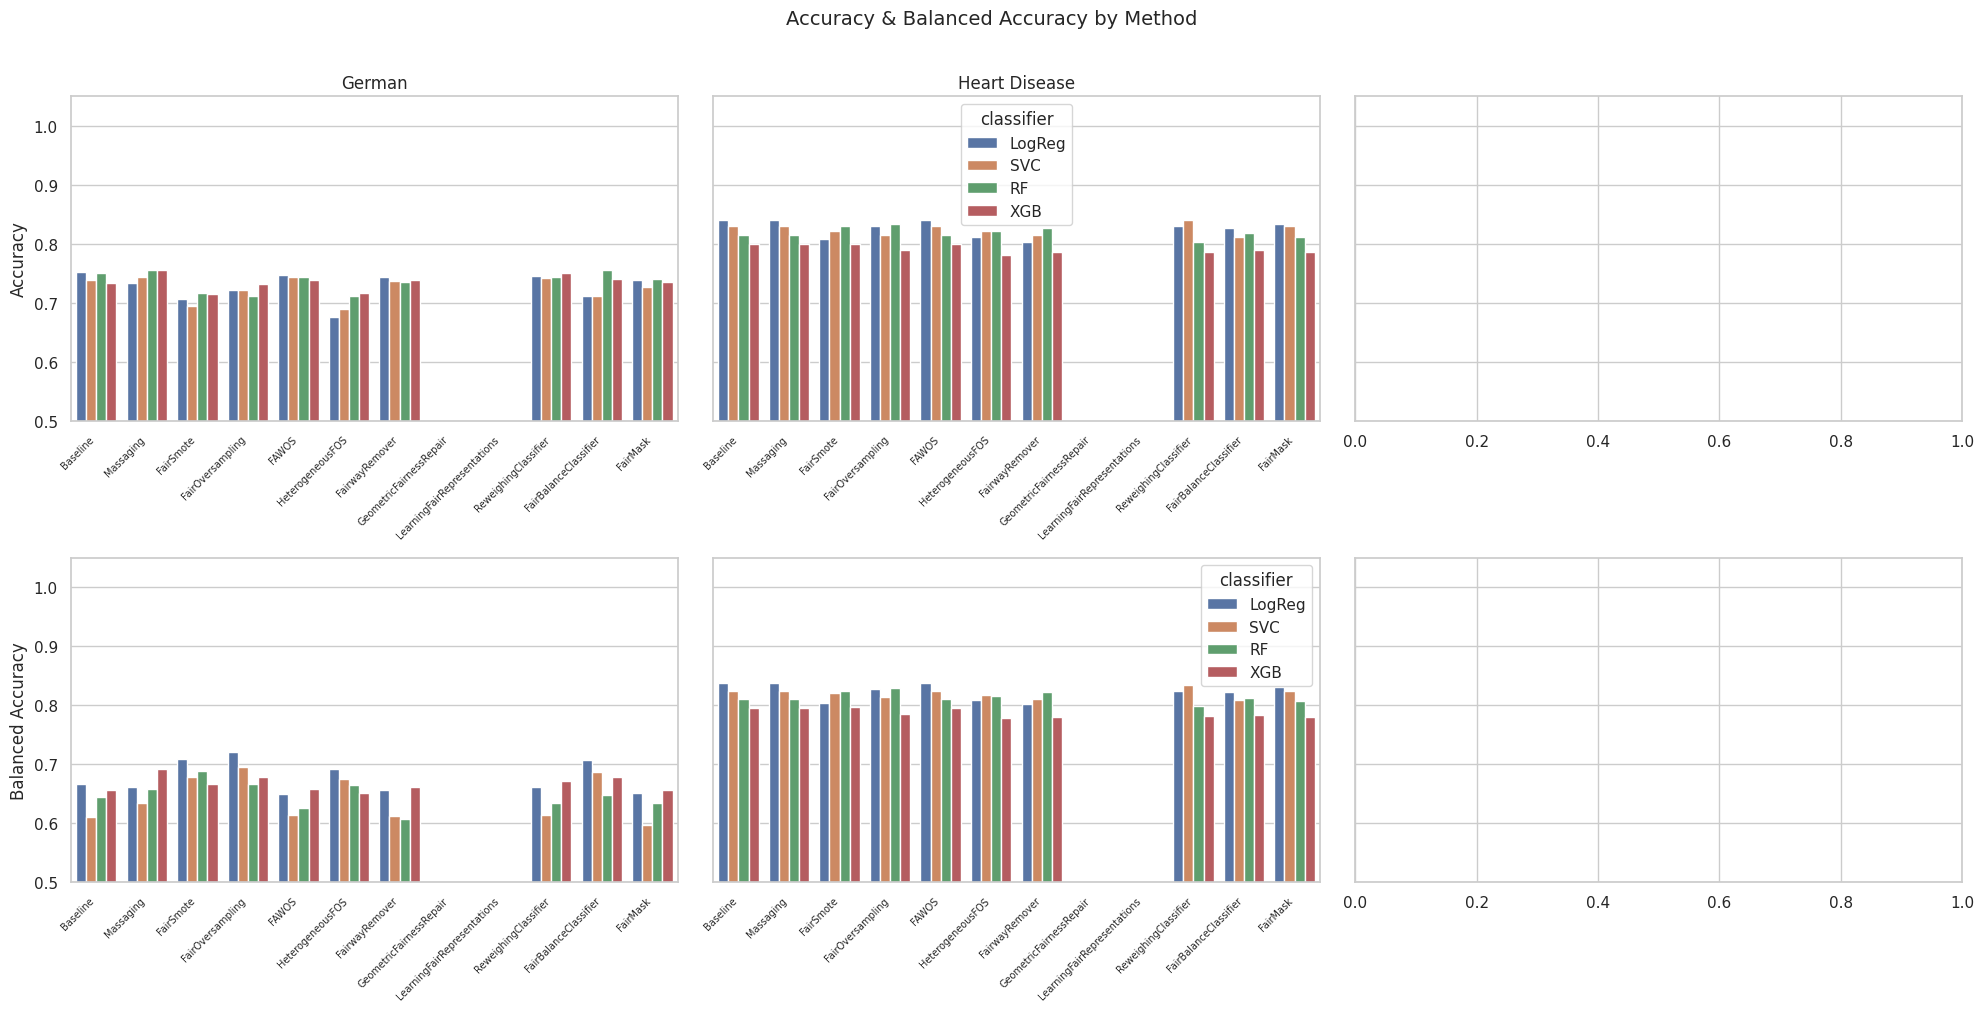

In [9]:
# --- Plot 1: Accuracy & Balanced Accuracy (hue=classifier, facet=dataset) ---
fig, axes = plt.subplots(2, 3, figsize=(20, 10), sharey="row")
row_metrics = ["accuracy_mean", "balanced_accuracy_mean"]
row_labels  = ["Accuracy", "Balanced Accuracy"]

for row_idx, (metric, ylabel) in enumerate(zip(row_metrics, row_labels)):
    for col_idx, dataset_name in enumerate(datasets):
        ax  = axes[row_idx, col_idx]
        sub = results_df[results_df["dataset"] == dataset_name].copy()
        sns.barplot(
            data=sub, x="method", y=metric, hue="classifier",
            ax=ax, errorbar=None,
        )
        ax.set_title(dataset_name if row_idx == 0 else "", fontsize=12)
        ax.set_ylabel(ylabel if col_idx == 0 else "")
        ax.set_xlabel("")
        ax.set_ylim(0.5, 1.05)
        ax.tick_params(axis="x", rotation=45)
        ax.set_xticklabels(ax.get_xticklabels(), ha="right", fontsize=7)
        if col_idx < len(datasets) - 1:
            legend = ax.get_legend()
            if legend:
                legend.remove()

plt.suptitle("Accuracy & Balanced Accuracy by Method", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

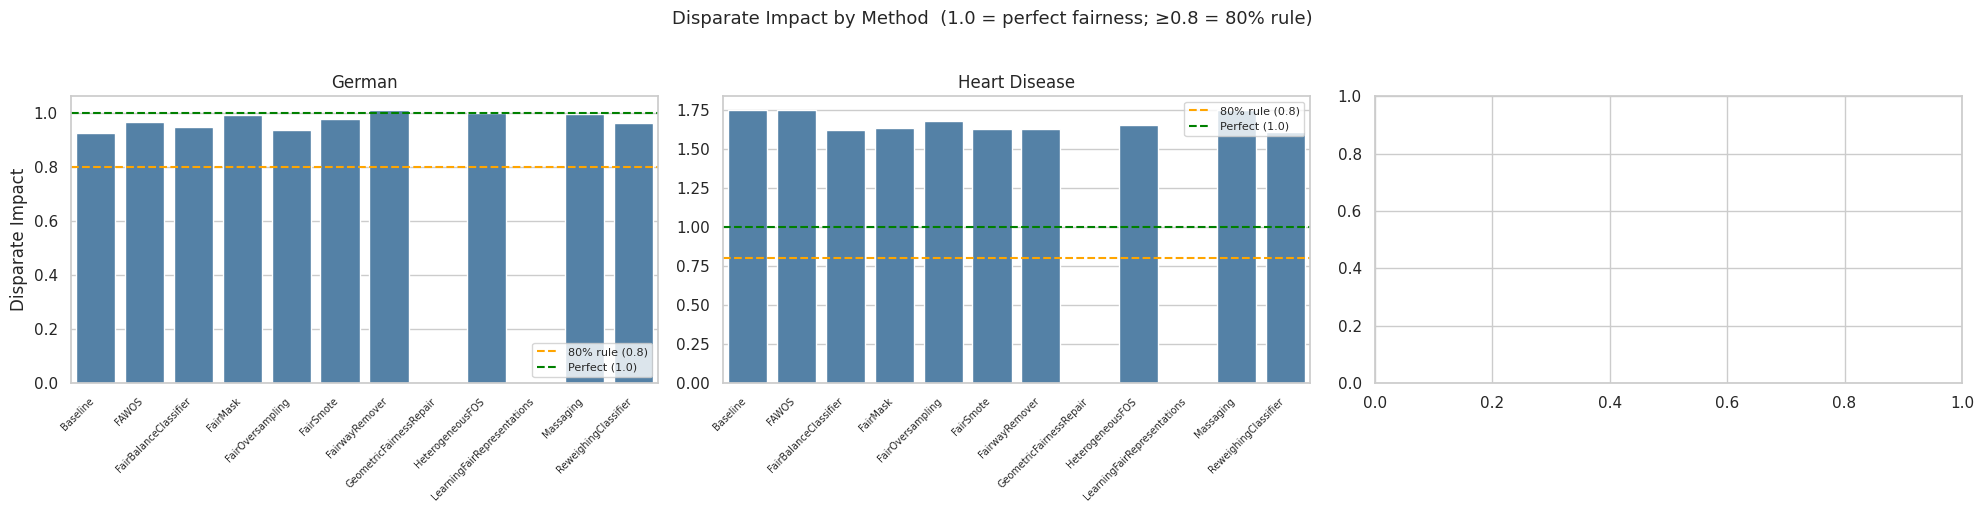

In [10]:
# --- Plot 2: Disparate Impact (averaged over classifiers, facet=dataset) ---
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

for ax, dataset_name in zip(axes, datasets):
    sub = results_df[results_df["dataset"] == dataset_name]
    agg = sub.groupby("method")["disparate_impact_mean"].mean().reset_index()
    sns.barplot(data=agg, x="method", y="disparate_impact_mean", ax=ax,
                color="steelblue", errorbar=None)
    ax.axhline(y=0.8, color="orange", linestyle="--", linewidth=1.5,
               label="80% rule (0.8)")
    ax.axhline(y=1.0, color="green",  linestyle="--", linewidth=1.5,
               label="Perfect (1.0)")
    ax.set_title(dataset_name, fontsize=12)
    ax.set_xlabel("")
    ax.set_ylabel("Disparate Impact" if ax is axes[0] else "")
    ax.tick_params(axis="x", rotation=45)
    ax.set_xticklabels(ax.get_xticklabels(), ha="right", fontsize=7)
    ax.legend(fontsize=8)

plt.suptitle("Disparate Impact by Method  (1.0 = perfect fairness; ≥0.8 = 80% rule)",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

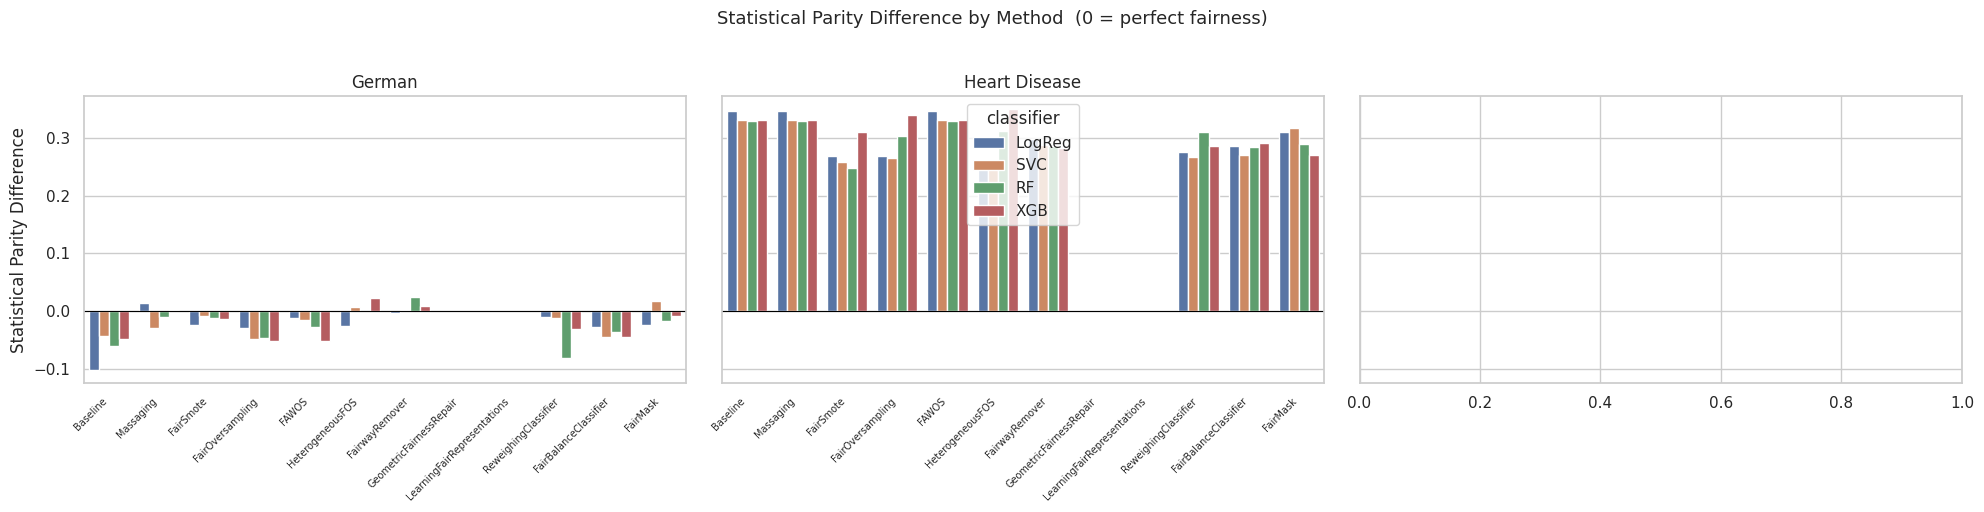

In [11]:
# --- Plot 3: Statistical Parity Difference (hue=classifier, facet=dataset) ---
fig, axes = plt.subplots(1, 3, figsize=(20, 5), sharey=True)

for col_idx, (ax, dataset_name) in enumerate(zip(axes, datasets)):
    sub = results_df[results_df["dataset"] == dataset_name].copy()
    sns.barplot(
        data=sub, x="method", y="spd_mean", hue="classifier",
        ax=ax, errorbar=None,
    )
    ax.axhline(y=0.0, color="black", linestyle="-", linewidth=0.8)
    ax.set_title(dataset_name, fontsize=12)
    ax.set_xlabel("")
    ax.set_ylabel("Statistical Parity Difference" if col_idx == 0 else "")
    ax.tick_params(axis="x", rotation=45)
    ax.set_xticklabels(ax.get_xticklabels(), ha="right", fontsize=7)
    if col_idx < len(datasets) - 1:
        legend = ax.get_legend()
        if legend:
            legend.remove()

plt.suptitle("Statistical Parity Difference by Method  (0 = perfect fairness)",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

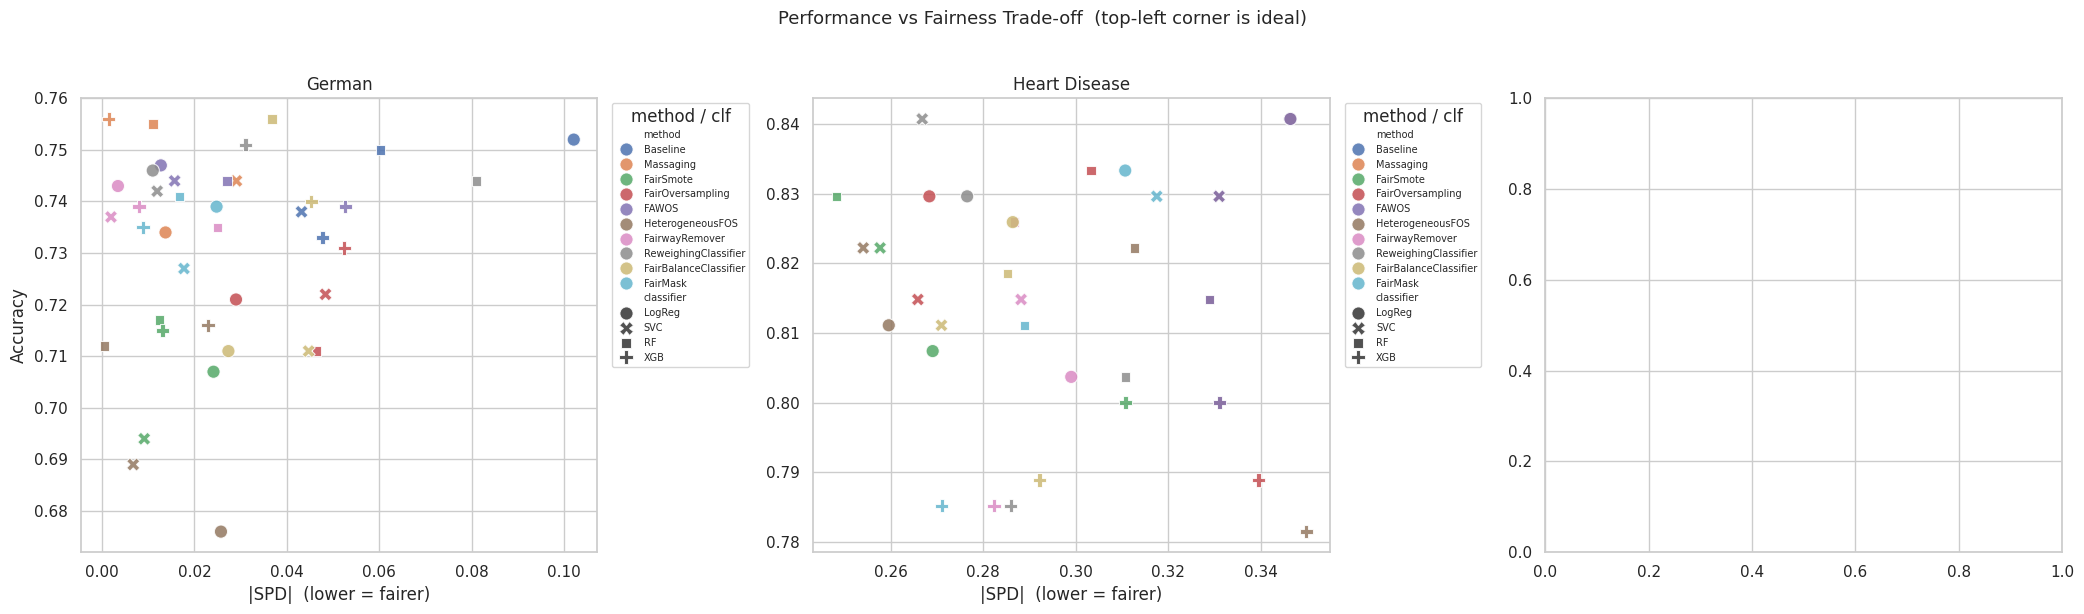

In [12]:
# --- Plot 4: Performance vs Fairness scatter ---
scatter_df = results_df.dropna(subset=["accuracy_mean", "spd_mean"]).copy()
scatter_df["abs_spd"] = scatter_df["spd_mean"].abs()

fig, axes = plt.subplots(1, 3, figsize=(21, 6))

for ax, dataset_name in zip(axes, datasets):
    sub = scatter_df[scatter_df["dataset"] == dataset_name]
    sns.scatterplot(
        data=sub, x="abs_spd", y="accuracy_mean",
        hue="method", style="classifier",
        ax=ax, alpha=0.85, s=90,
    )
    ax.set_title(dataset_name, fontsize=12)
    ax.set_xlabel("|SPD|  (lower = fairer)")
    ax.set_ylabel("Accuracy" if ax is axes[0] else "")
    ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=7,
              title="method / clf")

plt.suptitle("Performance vs Fairness Trade-off  (top-left corner is ideal)",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()